# Progradation vs Aggradation vs Retrogradation
### Connor van Wieren, 2025

In [12]:
todays_date = str(datetime.now())[:16] # lim  it to minutes
display(Markdown(f'### Date: {todays_date}'))
plt.style.use(light_style)

### Date: 2025-04-15 21:11

**Figures:**
1. demonstration image of progradational, retrogradational, and aggrdadational and why lazarus is less important in those

## Imports

In [51]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
#from pypalettes import load_cmap # for color palettes
import jax
import jax.numpy as jnp
from jax import  jit, random, lax, vmap
from jax.scipy.integrate import trapezoid as trapz
jax.config.update('jax_platform_name', 'cpu')
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.transforms import blended_transform_factory
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
from cycler import cycler
import seaborn as sns
import pandas as pd 
import time
import os
from scipy import signal
from scipy.stats import norm, uniform, gaussian_kde
from scipy.ndimage import gaussian_filter
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
import rasterio
import pickle
import dill
import sys
import string

# load funcs from .py files
sys.path.insert(0, '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/sed_transport/sed_transport')
from model_dev import run
from utils import *
from output import Model_output
from bahamas import load_geyman_bahamas

# import facies
sys.path.insert(0, '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Paleozoic_CIEs/notebooks/')
from facies import facies

# interactive plots
from ipywidgets import interactive, interact
from IPython.display import clear_output, Video

np.set_printoptions(threshold=np.inf,linewidth=np.inf)

fig_dir = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Paleozoic_CIEs/figures/'
sem_dir = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Talks/UVic_Department_Talks/Exit Seminar/img/' # for exit seminar
tex_fig_dir = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Publications/Ch2_Paleozoic_CIE_EPSL/img/'
data = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Paleozoic_CIEs/data/'
## load geyman bahamas facies data
#subset_land, subset_ms, subset_ws, subset_ps, subset_ogs, subset_sgs = load_geyman_bahamas(downsample=5000,plot=False)

# Model setup

In [14]:
# from the current method
params = {'Nx':400,        # was 200; 400
          'xmin':0,
          'xmax':6000,     # was 180, scaled up, just need to change slope of hi
          'dx':0.8, #'none',     # 0.1 # if none defaults to (xmax-xmin)/(Nx); 0.8
          'start':0,
          'dt':0.1,
          'total_n':2000,
          'compiled_steps':100,
          'pel_epsilon':0,   # ‰; 1.5
          'alg_epsilon':0,
          'coral_epsilon':0,
          'ocean_depth':0,  # depth at which seawater reflects open ocean
          'marine_K':2.5e-1,   # 1e-2; 1.5e-1
          'land_K':5e-1,   # 2e-2; 2.5e-1
          'smooth_K':6,      # was 10; the lower it is the more of a sharp step function it is
          'ylen':1000,       # 10000; I really don't think it needs to be this big
          'A':0.1}             # 0.01 0.1, I think needs to be smaller to scale with small magnitude of this run's topography changes
                             # A needs to be tuned. If A too big or too small, model provides unrealistic or incorrect functionality

# build time and space constraints for initial condition setting and initiation functions (sl, growth, etc.)
x,t,end = init_vars(params)

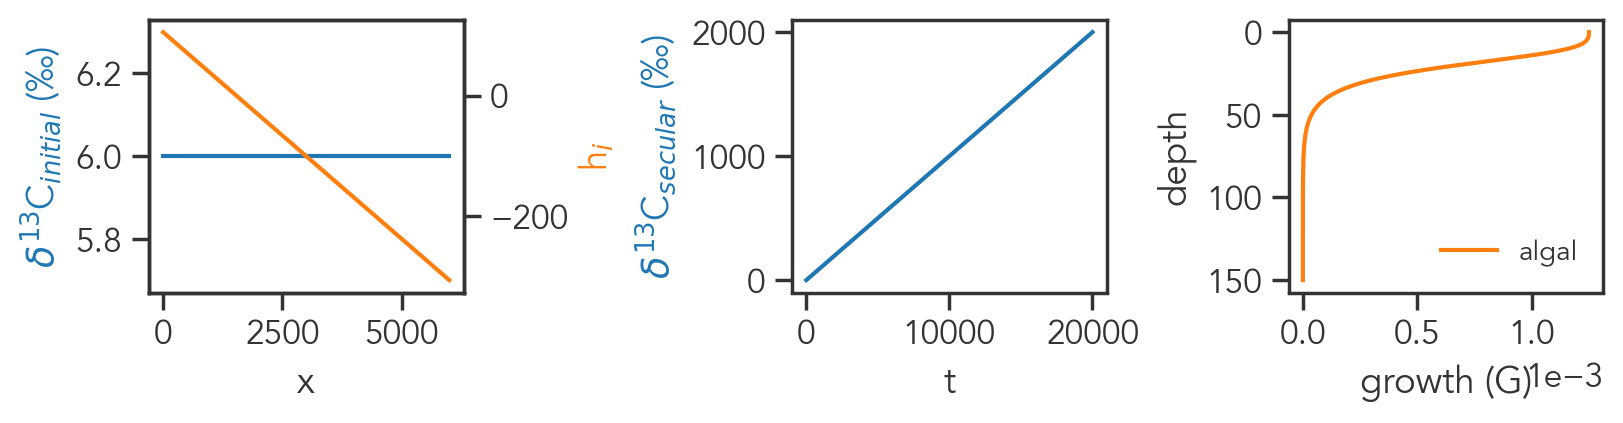

In [15]:
## Define h: initial topographic composition
h = -0.0685*x+105 # for xmax of 6000; slope chosen to match bahamas aspect ratio

## Define w: initial proxy composition
wi_p = jnp.ones_like(h)*6 # shallow value boundary condition for positive run

# secular w array
#sec_w_fun_sec1 = lambda t: t/5000 +1
sec_w_fun = lambda t: t/10

## Define w: initial proxy composition
wi_m = jnp.ones_like(h)*sec_w_fun(t)[0] # first secular value value boundary condition

fig,ax = plt.subplots(1,3,figsize=(8,2),layout='constrained')

# initial proxy and topography
ax[0].plot(x,wi_p,label='$\\delta^{13}$C$_{initial}$ (‰)',color='tab:blue') # showing index not actual units
axi = ax[0].twinx()
axi.plot(x,h,label='h$_i$',color='tab:orange') # showing index not actual units
ax[0].set_xlabel('x')
ax[0].set_ylabel('$\\delta^{13}$C$_{initial}$ (‰)',color='tab:blue')
axi.set_ylabel('h$_i$',color='tab:orange')

# proxy over time
ax[1].plot(t,sec_w_fun(t),color='tab:blue')
ax[1].set_ylabel('$\\delta^{13}$C$_{secular}$ (‰)',color='tab:blue')
ax[1].set_xlabel('t');

## Growth Functions ##
z = np.linspace(1e-5,150,1000) # depth

# functions for model -> dt seems to need to be 0 for both of them to work properly with the weighted average. otherwise get pelagic growth way too shallow than should be possible 
Dt_alg = 0 #5 # maybe this is a solution for a lag parameter
algal_growth = lambda x: bosscher_G(x,Gm=0.00125,out='growth',Dt=Dt_alg)

# pelagic growth
ax[2].plot(algal_growth(z),z,color='tab:orange',label='algal',ls='-')
ax[2].set_xlabel('growth (G)')
ax[2].legend(frameon=False)
ax[2].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[2].set_ylabel('depth')
ax[2].invert_yaxis()

## Progradational
- constant (or slowly rising or falling) sea level, high sed rate. Doing constant here

0.0


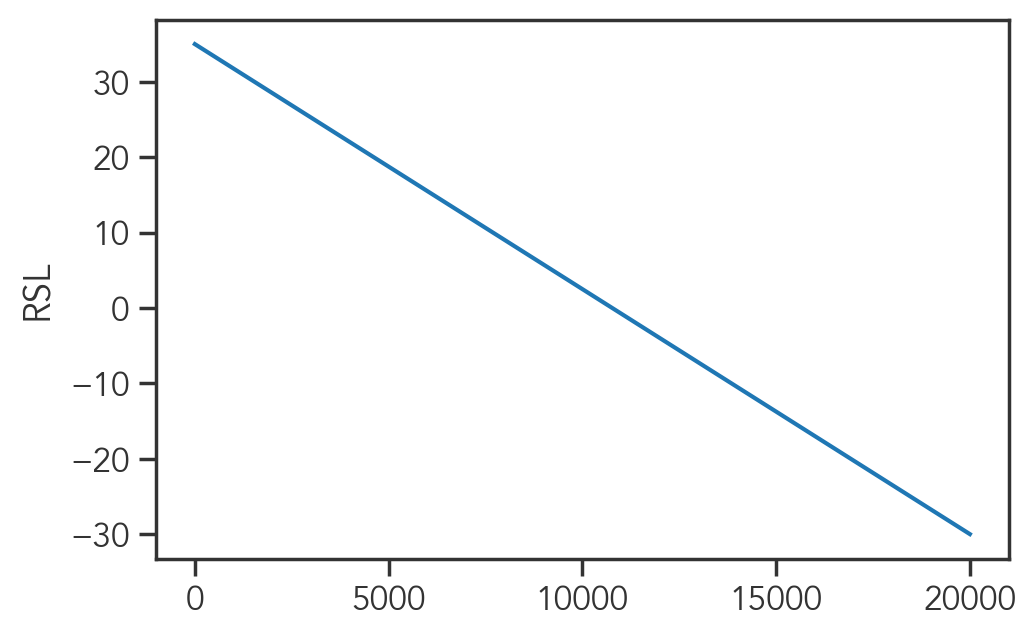

In [16]:
# sea level
#sl_fun = lambda t: jnp.ones_like(t)+35
#sl_fun1 = lambda t: 35*jnp.sin((t+23500)/8750)+20 # wanted a more distinct looking prograde
sl_fun_prog = lambda t: -0.00325*t+35 # even simpler distinct prograding with lower sea level

plt.plot(t,sl_fun_prog(t))
# plt.plot(t,sl_fun1(t))
# plt.plot(t,sl_fun2(t))

plt.ylabel('RSL')

## Define w: initial proxy composition
wi = jnp.ones_like(h)*sec_w_fun(t)[0] # first secular value value boundary condition
print(wi_m[0])

calculated ymin,ymax = -341.00, 140.00
mean grid dy = 4.815e-01


running model: progradational_A0.1_ylen1000_2025-04-15 21:11:   0%|          | 0/2000 [00:00<?, ? compiled ste…

plotting results:   0%|          | 0/2000 [00:00<?, ? beds/s]

actual ymin,ymax = -306.00, 105.00


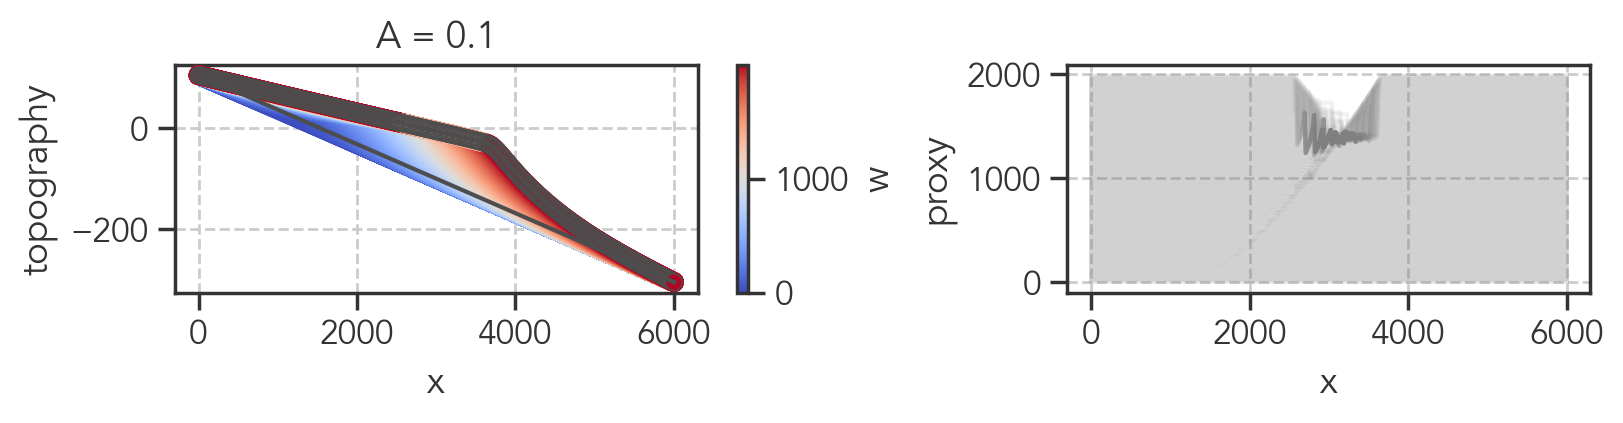

In [17]:
## name of model
desc = 'progradational' 

mod_prog = run(params,                           
          model_desc = desc,                 
          hi = h,                           
          wi = wi,                            
          wi_sec = True,                     
          sl_fun = sl_fun_prog,                   
          sec_w_fun = sec_w_fun,            
          depth_w_fun = None,        
          growth_fun_alg = algal_growth,    
          alg_coef = 5.5,   # 8.5               
          plot_skip = 10,
          const_K = False,
          w_set_erode = True,               
          full_storage = False,
          figsize=(8,2),
          normalize_balance=True)

max depth = 411.00


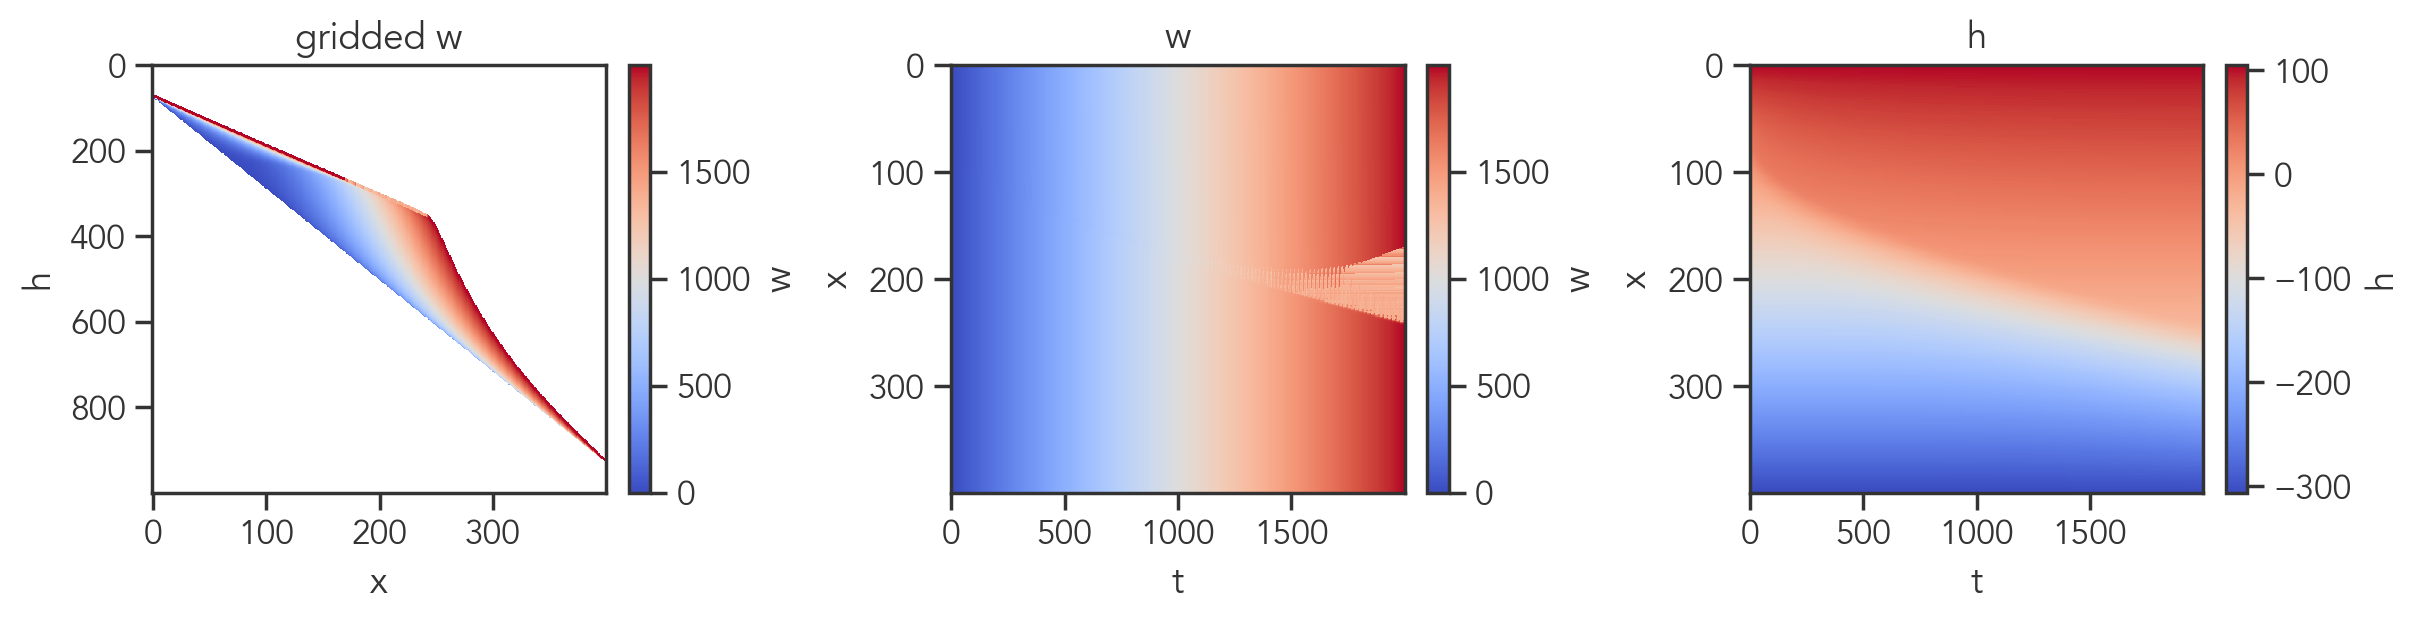

In [53]:
# define max depth
max_depth = np.nanmax(mod_prog['ds'])
print(f'max depth = {max_depth:.2f}')

# simple version with fewer facies and just depth ranges
#facies_data = facies(max_depth)
# simple version with fewer facies and just depth ranges
facies_data = [{'name':'Terrestrial','type': 'land','width':1,'min':1,'max':2}, # terrestrial is always everyting <0 (above water)
               {'name':'Grainstone','type': 'uniform', 'min': -0.01, 'max': max_depth/20,'width':.8}, # need this slightly modified min and the threshold below to make it work well
               {'name':'Packstone','type': 'uniform', 'min': max_depth/20, 'max': max_depth/15,'width':.6},
               {'name':'Wackestone','type': 'uniform', 'min': max_depth/15, 'max': max_depth/12,'width':.4},
               {'name':'Mudstone','type': 'uniform', 'min': max_depth/12, 'max': max_depth/10,'width':.3},
               {'name':'Shallow Marine','type': 'uniform', 'min': max_depth/10, 'max': max_depth/8,'width':.3},
               {'name':'Intermediate Marine','type': 'uniform', 'min': max_depth/8, 'max': max_depth/5,'width':.2},
               {'name':'Deep Marine','type': 'uniform', 'min': max_depth/5, 'max': max_depth,'width':.2}]


# facies colours # my_pal
facies_colours = list(sns.color_palette('BrBG',n_colors=len(facies_data)+1).as_hex()) # add one as going to drop the white one
facies_colours.pop(5) # drop the white one # was 4
sns.color_palette(facies_colours) # look at the palette

## model outputs
out_prog = Model_output(**mod_prog,facies_data=facies_data,facies_colours=facies_colours,bc_filter=False,set_under_c='.3',im_ylen=5000,images=True)
out_prog.plot_grids()

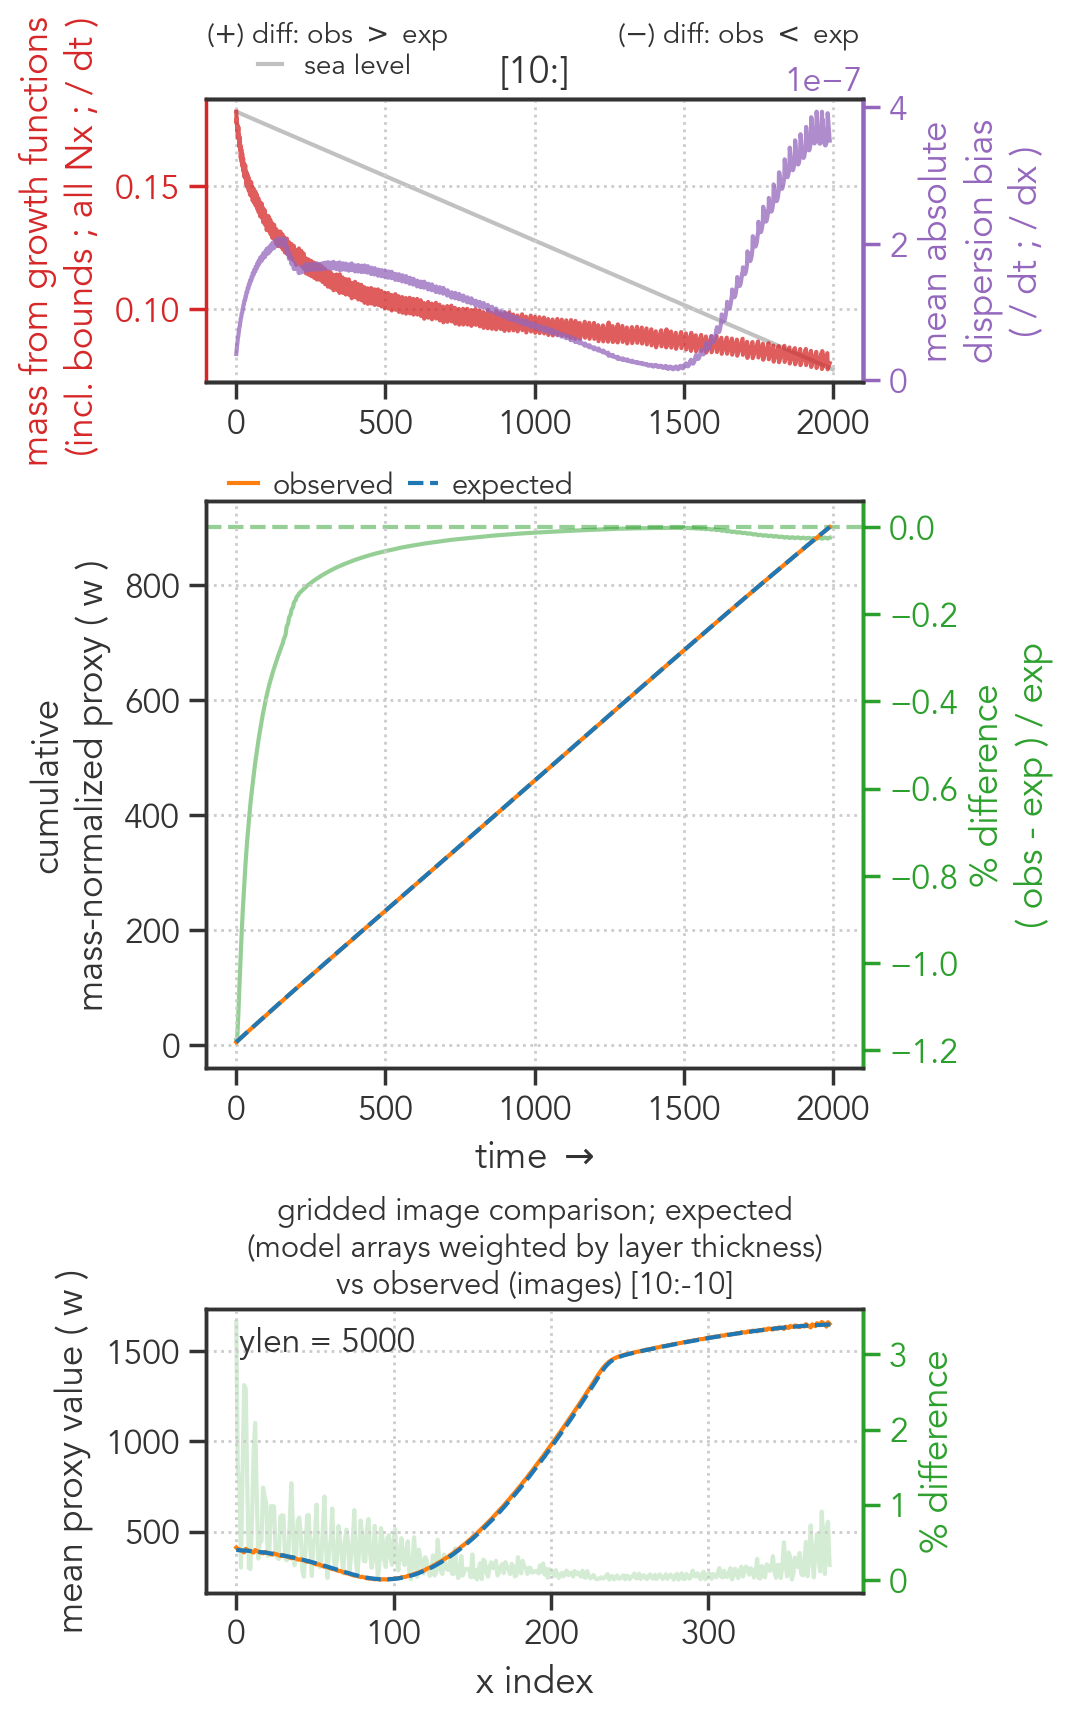

In [19]:
fig,ax,diff = out_prog.mass_balance(out=True,rsl=True,percent=True,show='proxy',start=10,im_l_lim=10,im_r_lim=-10)

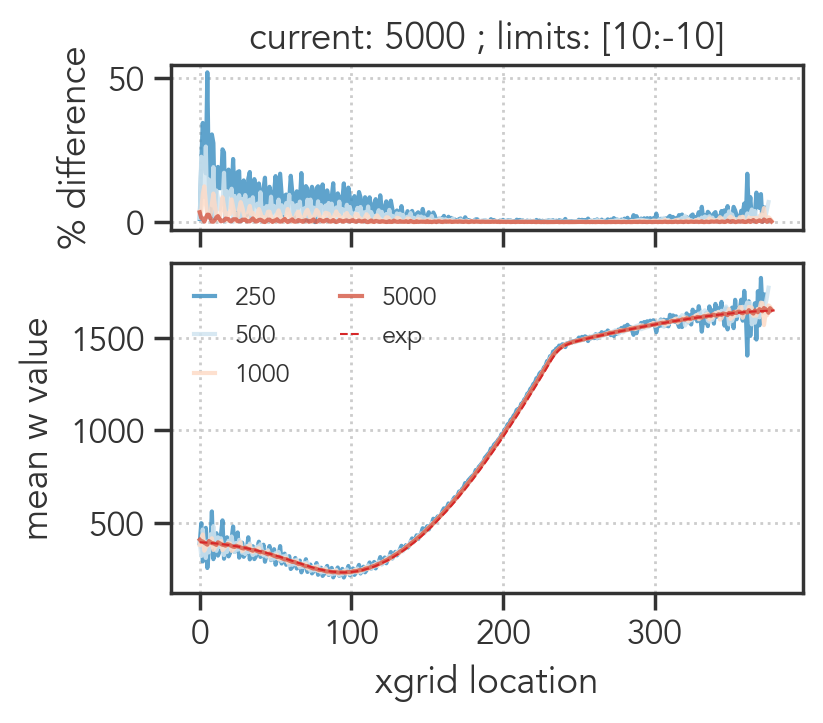

In [20]:
fig = out_prog.im_res_compare(pal='RdBu_r',ncols='multi',im_l_lim=10,im_r_lim=-10)

## Aggradational
- want stacked regressional cycles

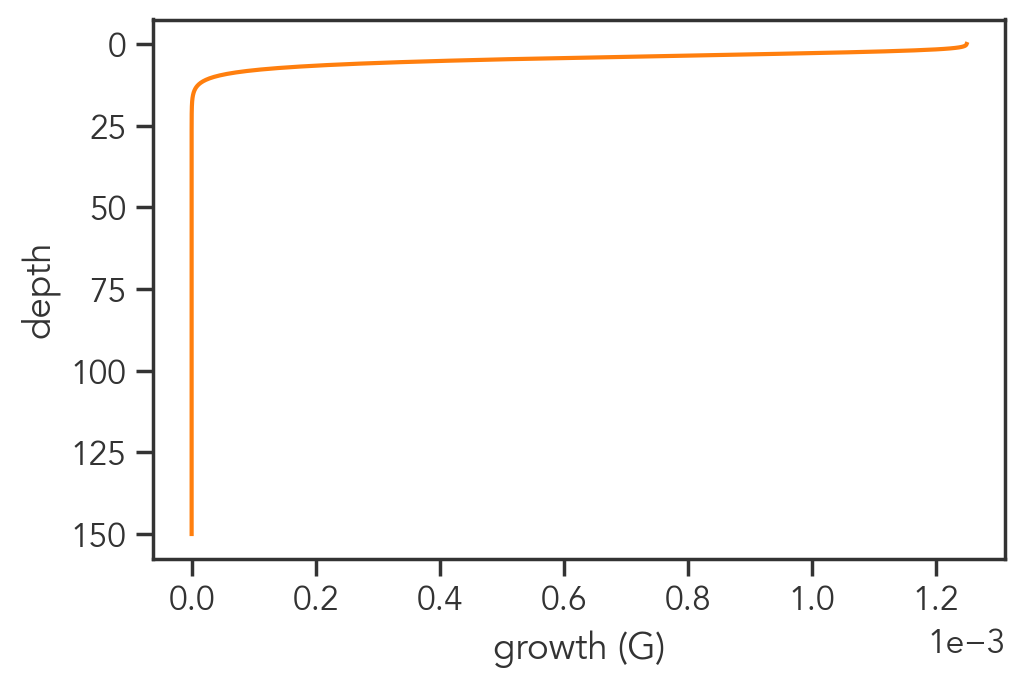

In [21]:
## Growth Functions ##
## dummy depth data
z = np.linspace(1e-5,150,1000)

Dt_alg = 0 #5 # maybe this is a solution for a lag parameter
algal_growth_agg = lambda x: bosscher_G(x,Gm=0.00125,out='growth',Dt=Dt_alg,k=0.5) # default k=0.1

# pelagic growth
plt.plot(algal_growth_agg(z),z,color='tab:orange',label='algal',ls='-')
plt.xlabel('growth (G)')
plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ylabel('depth')
plt.gca().invert_yaxis()

In [22]:
# sawtooth for stacking parasequences (this one works super well but ends up being unrealistic as instantaneous sl rise. also removes lazarus beds as instantaneous)
def ssawtooth(t,amplitude, period, rise, drop):
    sawtooth_wave = amplitude * (1 - (t % period) / period) + rise*t - drop
    return sawtooth_wave

# sawtooth for stacking parasequences
def triangle_sawtooth(t,frequency, amplitude, rise,drop):
    waveform = amplitude * (2 * np.arcsin(np.sin(2 * np.pi * frequency * t)) / np.pi) + rise*t - drop
    return waveform

def variable_sawtooth(t,frequency,amplitude,rise_fraction,rise,drop):
    # Generate the waveform
    waveform = np.zeros_like(t)
    period = 1 / frequency
    for i in range(len(t)):
        cycle_position = t[i] % period
        if cycle_position < rise_fraction * period:
            waveform[i] = (cycle_position / (rise_fraction * period)) * amplitude + rise*t[i] - drop
        else:
            waveform[i] = amplitude - ((cycle_position - rise_fraction * period) / ((1 - rise_fraction) * period)) * amplitude + rise*t[i] - drop

    return waveform


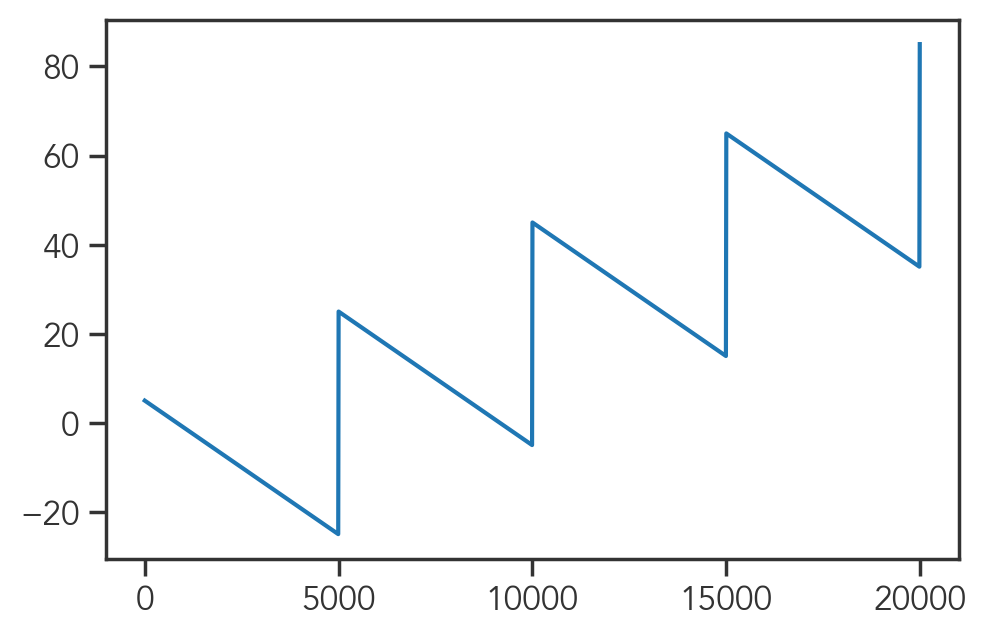

In [23]:
wave = ssawtooth(t,amplitude=50, period=2.5, rise=0.004, drop=45)
plt.plot(t,wave,label='saw')

# allow for use in jax jit 
sl_fun_saw = lambda i: jnp.interp(i,t,wave)

In [24]:
# def modified_ssawtooth(t, amplitude, period, rise, drop, fall_factor=1.5):
#     # The `fall_factor` controls the sharpness of the fall.
#     cycle_position = (t % period) / period
#     waveform = np.where(
#         cycle_position < 0.9,  # Rise phase, modify the threshold to control the rise duration
#         amplitude * (1 - cycle_position),  # Rising
#         amplitude * (1 - cycle_position) - (fall_factor * drop)  # Falling with adjusted intensity
#     ) + rise * t
#     return waveform

# # Parameters
# t = np.linspace(0, 20000, 2000)
# wave = modified_ssawtooth(t, amplitude=50, period=2.5, rise=0.004, drop=45, fall_factor=1.8)

# # Plotting
# plt.plot(t, wave, label='Modified Sawtooth with Sharper Falls')
# sl_fun_saw = lambda i: jnp.interp(i,t,wave)

calculated ymin,ymax = -391.00, 190.00
mean grid dy = 5.816e-01


running model: aggradational_A0.1_ylen1000_2025-04-15 21:19:   0%|          | 0/2000 [00:00<?, ? compiled step…

plotting results:   0%|          | 0/2000 [00:00<?, ? beds/s]

actual ymin,ymax = -306.00, 105.00


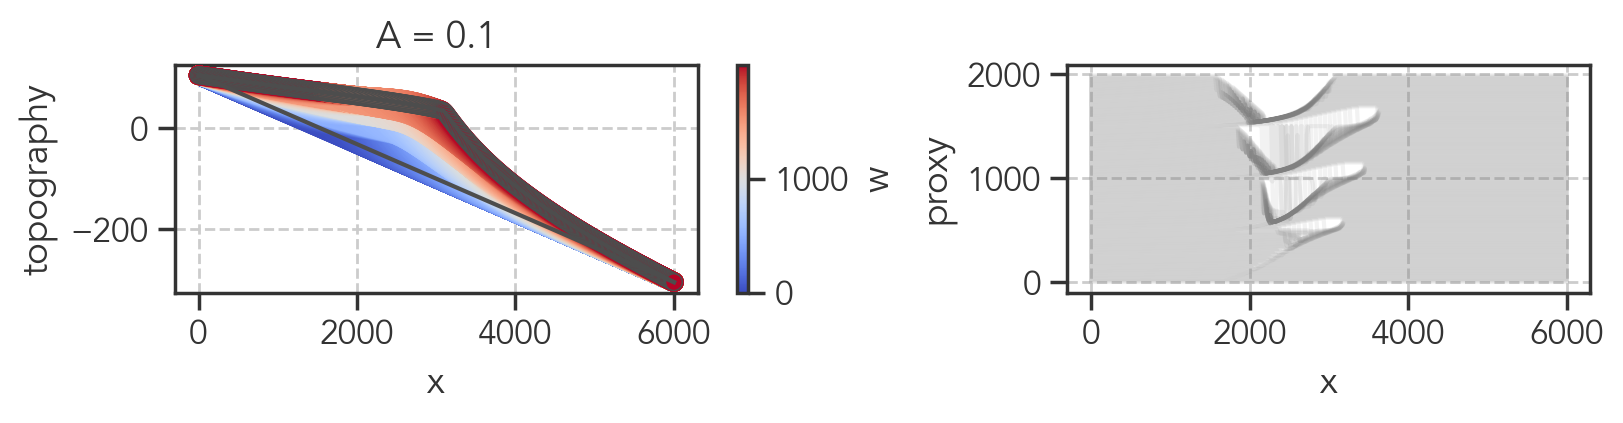

In [25]:
# name of model
desc = 'aggradational' 

mod_agg = run(params,                           
          model_desc = desc,                 
          hi = h,                           
          wi = wi,                            
          wi_sec = True,                     
          sl_fun = sl_fun_saw,                   
          sec_w_fun = sec_w_fun,            
          depth_w_fun = None,        
          growth_fun_alg = algal_growth_agg,    
          alg_coef = 28.5, #  8.5
          plot_skip = 10,                    
          w_set_erode = True,               
          full_storage = False,
          figsize=(8,2))

max depth = 411.00


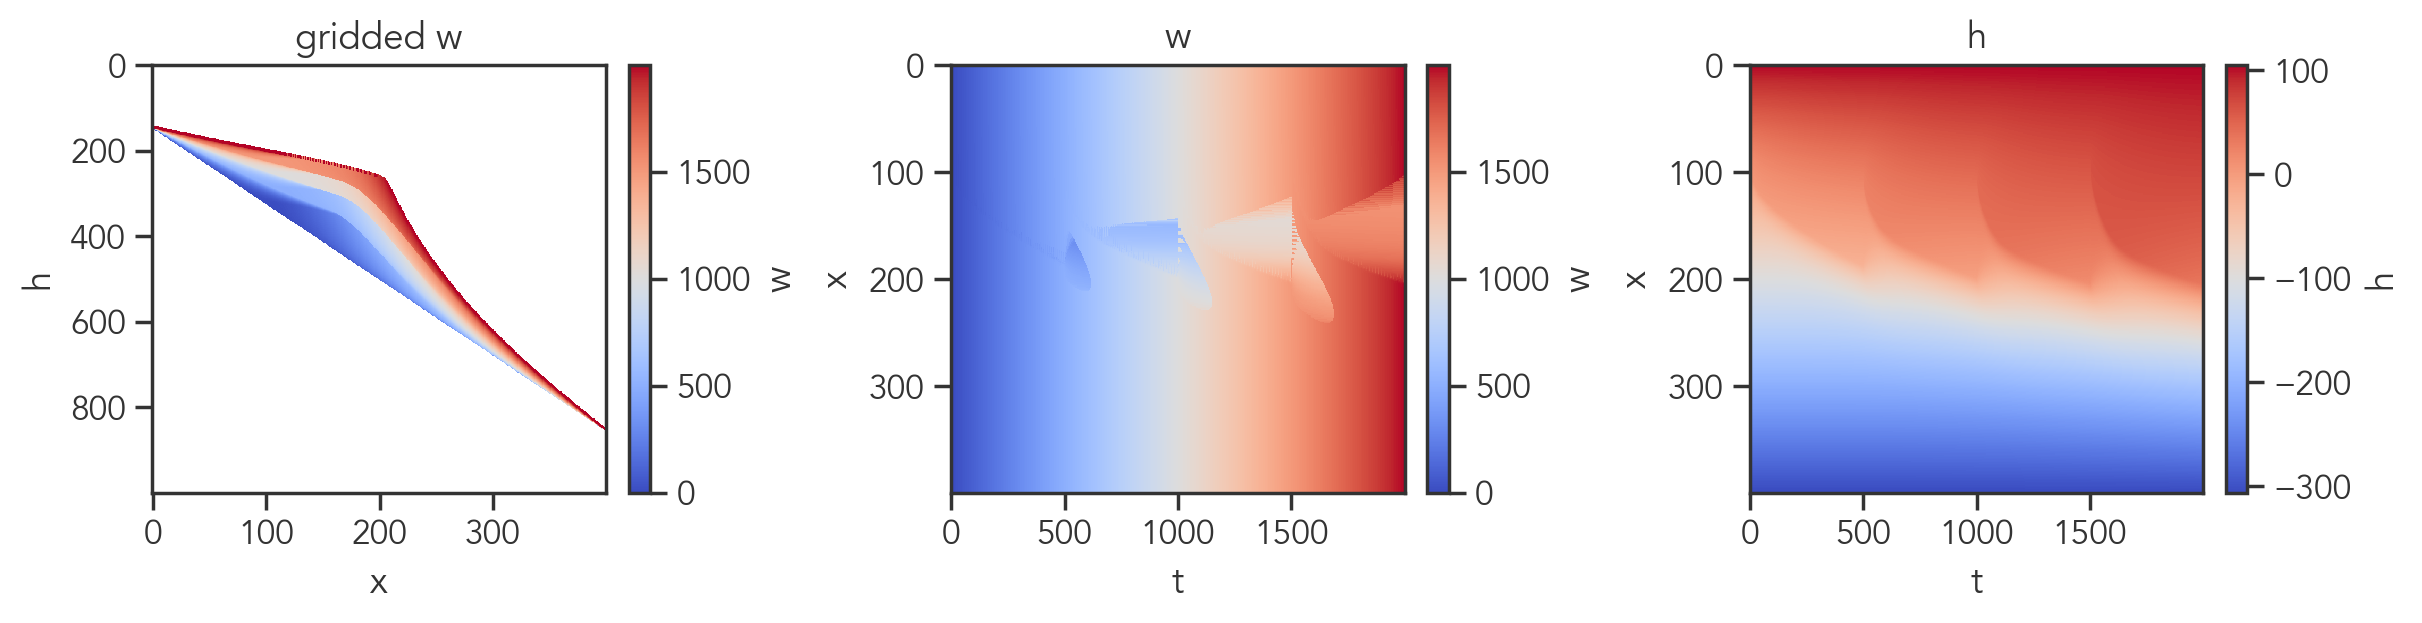

In [54]:
# define max depth
max_depth = np.nanmax(mod_agg['ds'])
print(f'max depth = {max_depth:.2f}')

# simple version with fewer facies and just depth ranges
#facies_data = facies(max_depth)
facies_data = [{'name':'Terrestrial','type': 'land','width':1,'min':1,'max':2}, # terrestrial is always everyting <0 (above water)
               {'name':'Grainstone','type': 'uniform', 'min': -0.01, 'max': max_depth/20,'width':.8}, # need this slightly modified min and the threshold below to make it work well
               {'name':'Packstone','type': 'uniform', 'min': max_depth/20, 'max': max_depth/15,'width':.6},
               {'name':'Wackestone','type': 'uniform', 'min': max_depth/15, 'max': max_depth/12,'width':.4},
               {'name':'Mudstone','type': 'uniform', 'min': max_depth/12, 'max': max_depth/10,'width':.3},
               {'name':'Shallow Marine','type': 'uniform', 'min': max_depth/10, 'max': max_depth/8,'width':.3},
               {'name':'Intermediate Marine','type': 'uniform', 'min': max_depth/8, 'max': max_depth/5,'width':.2},
               {'name':'Deep Marine','type': 'uniform', 'min': max_depth/5, 'max': max_depth,'width':.2}]

# facies colours # my_pal
facies_colours = list(sns.color_palette('BrBG',n_colors=len(facies_data)+1).as_hex()) # add one as going to drop the white one
facies_colours.pop(5) # drop the white one # was 4
sns.color_palette(facies_colours) # look at the palette

## model outputs
out_agg = Model_output(**mod_agg,facies_data=facies_data,facies_colours=facies_colours,bc_filter=False,set_under_c='.3',im_ylen=5000,tol=5,images=True)
out_agg.plot_grids()

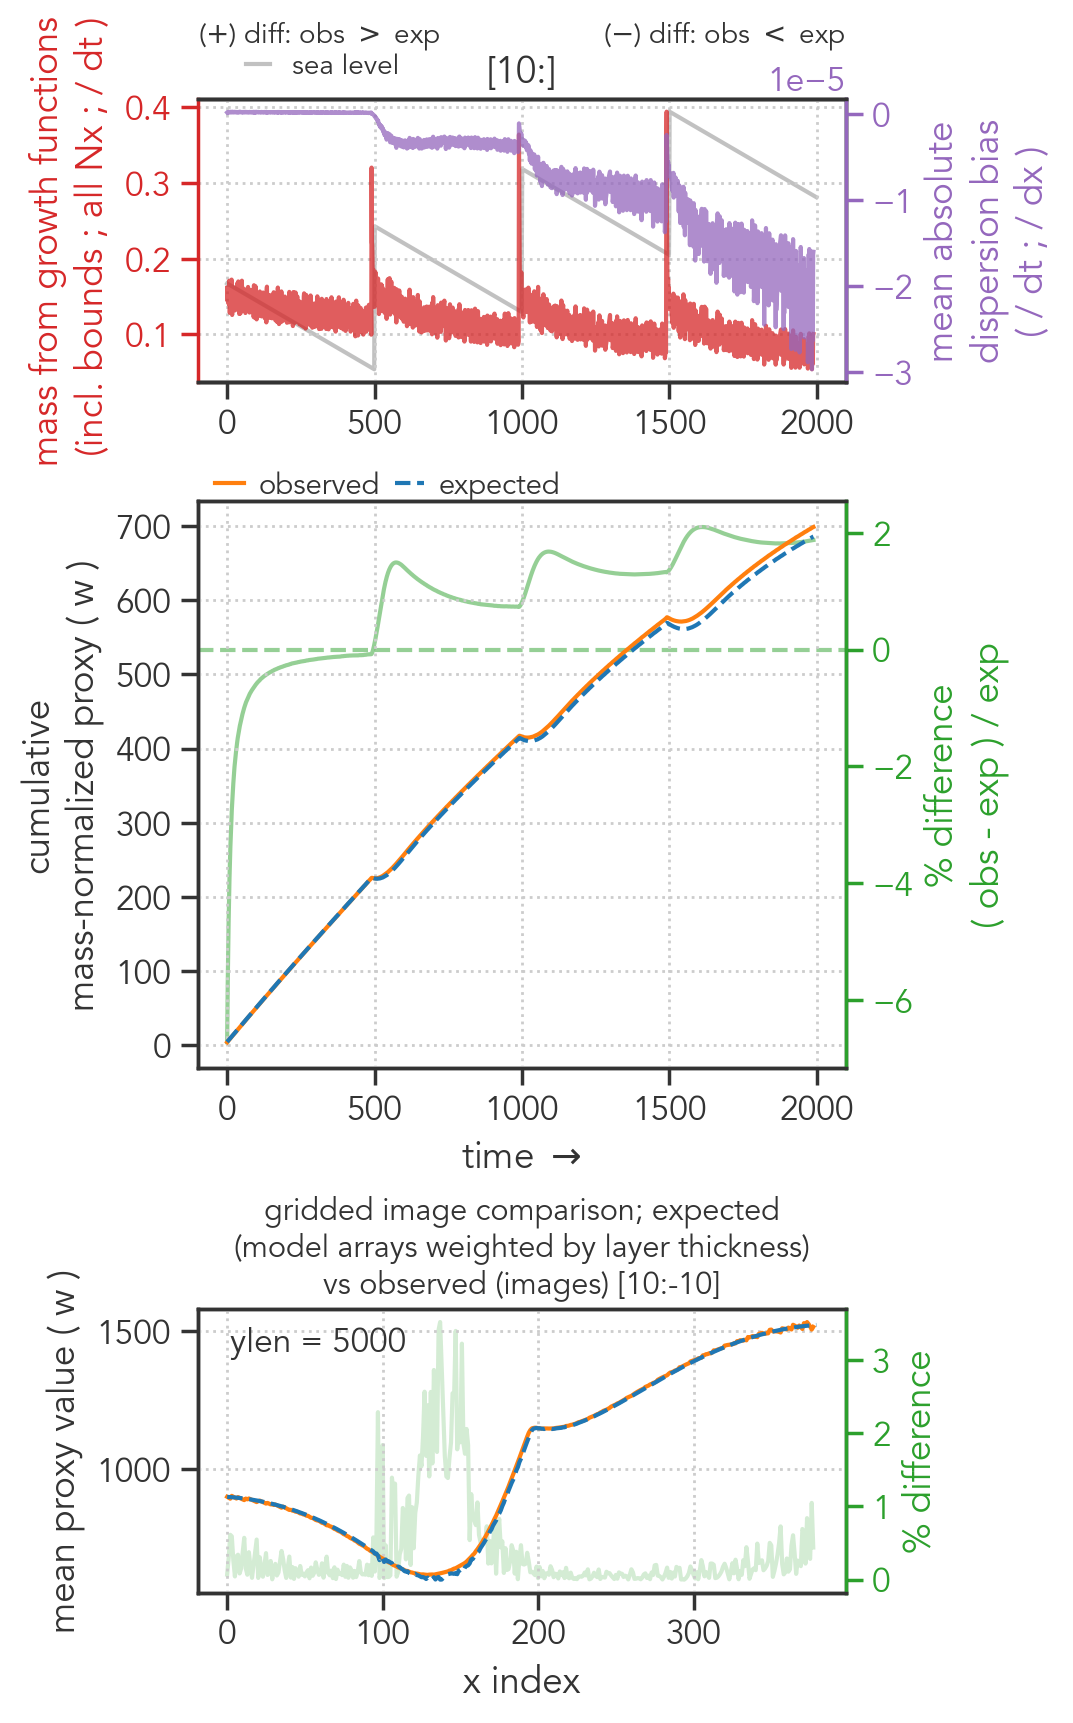

In [27]:
fig,ax,diff = out_agg.mass_balance(out=True,rsl=True,percent=True,show='proxy',start=10,im_l_lim=10,im_r_lim=-10)

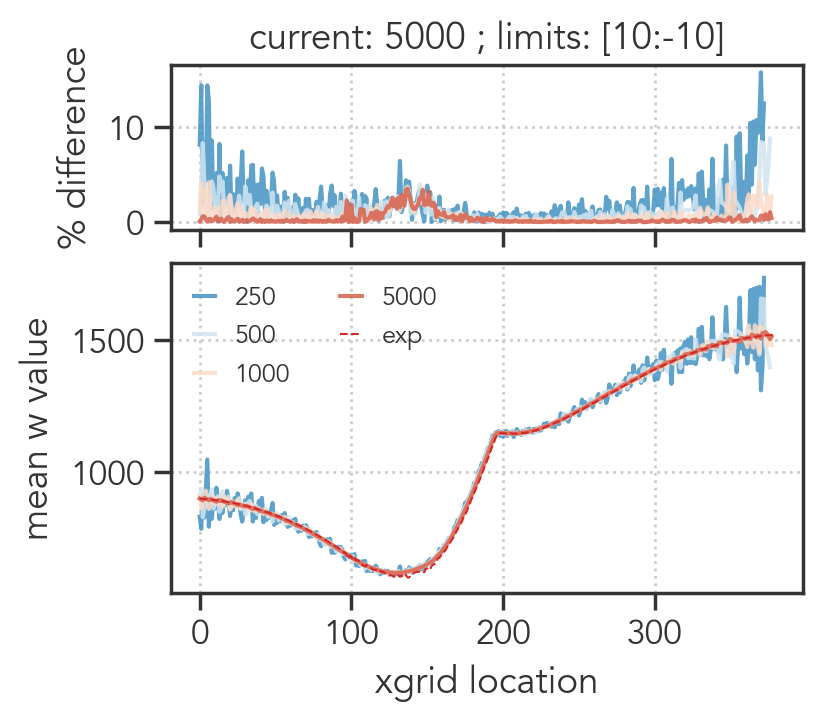

In [28]:
fig = out_agg.im_res_compare(pal='RdBu_r',ncols='multi',im_l_lim=10,im_r_lim=-10)

## Retrogradational
- accomodation exceeds sed supply. Made a shallow biased groth column (same as for aggradational) and then made a sea level rise

0.0


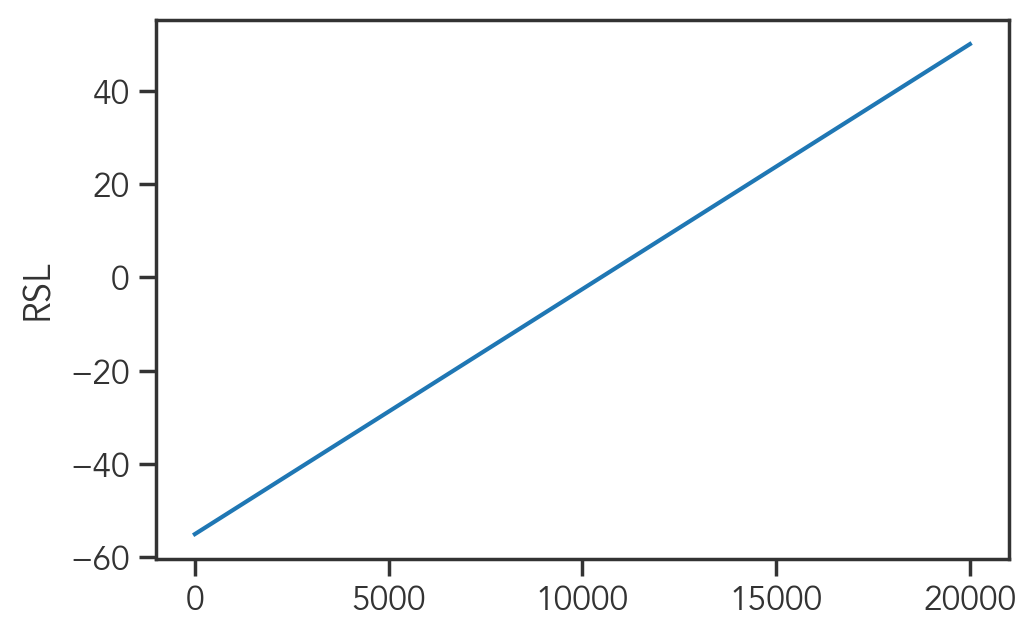

In [32]:
# sea level
sl_fun_reg = lambda t: 0.00525*t-55 # even simpler distinct prograding with lower sea level

plt.plot(t,sl_fun_reg(t))
# plt.plot(t,sl_fun1(t))
# plt.plot(t,sl_fun2(t))

plt.ylabel('RSL')

## Define w: initial proxy composition
wi = jnp.ones_like(h)*sec_w_fun(t)[0] # first secular value value boundary condition
print(wi_m[0])

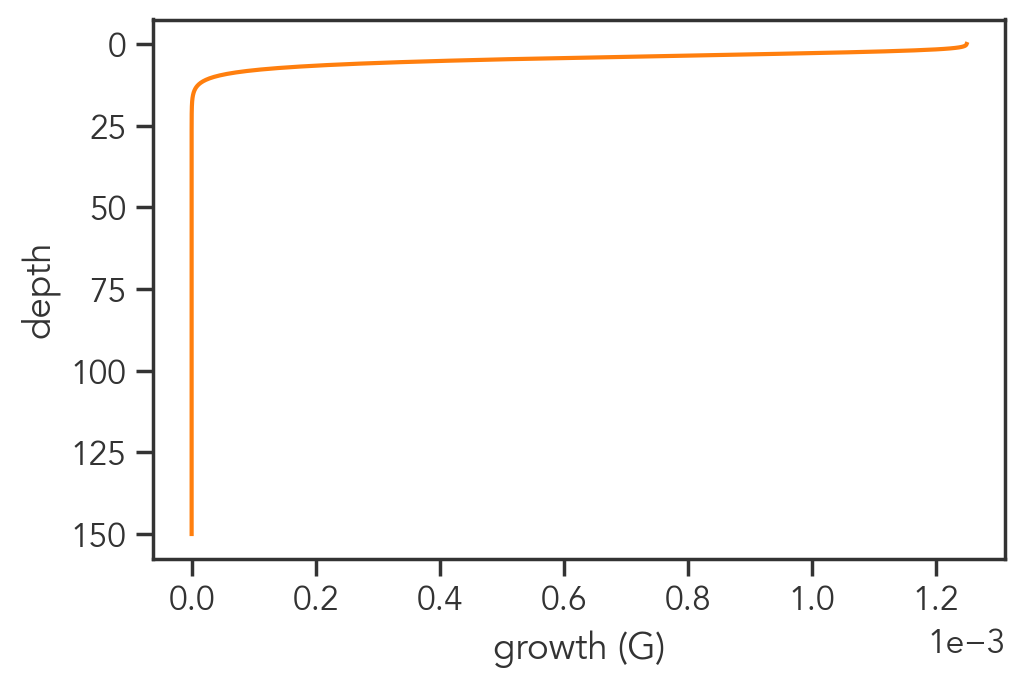

In [33]:
algal_growth_reg = lambda x: bosscher_G(x,Gm=0.00125,out='growth',Dt=Dt_alg,k=0.5) # default k=0.1

# pelagic growth
plt.plot(algal_growth_reg(z),z,color='tab:orange',label='algal',ls='-')
plt.xlabel('growth (G)')
plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ylabel('depth')
plt.gca().invert_yaxis()

calculated ymin,ymax = -361.00, 160.00
mean grid dy = 5.215e-01


running model: retroradational_A0.1_ylen1000_2025-04-15 21:31:   0%|          | 0/2000 [00:00<?, ? compiled st…

plotting results:   0%|          | 0/2000 [00:00<?, ? beds/s]

actual ymin,ymax = -306.00, 105.00


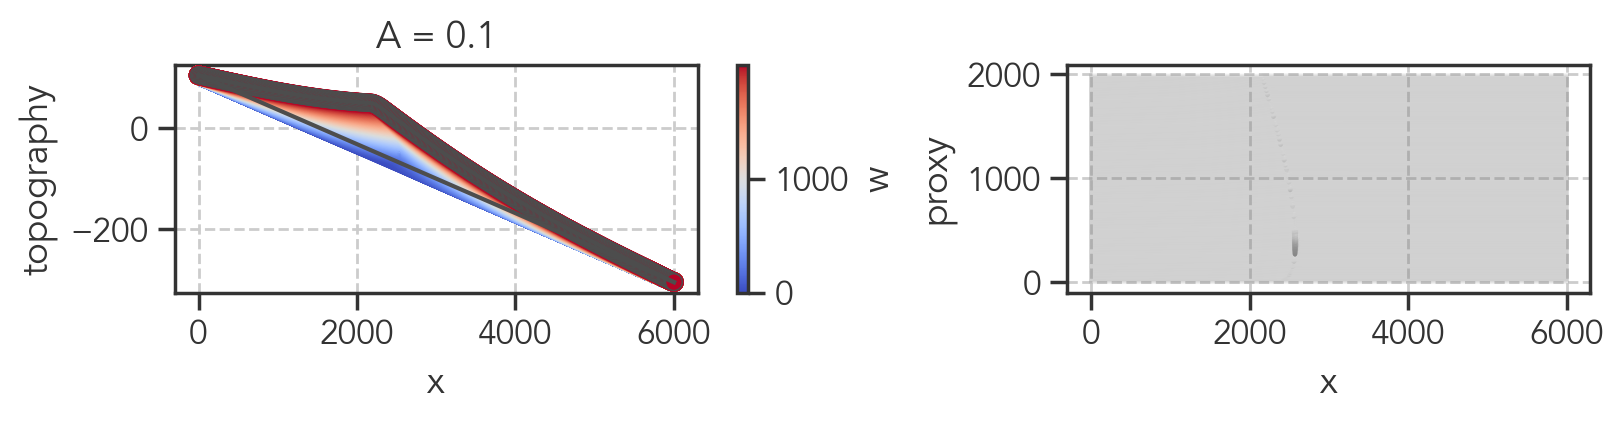

In [34]:
## name of model
desc = 'retroradational' 

mod_reg = run(params,                           
          model_desc = desc,                 
          hi = h,                           
          wi = wi,                            
          wi_sec = True,                     
          sl_fun = sl_fun_reg,                   
          sec_w_fun = sec_w_fun,            
          depth_w_fun = None,        
          growth_fun_alg = algal_growth_reg,    
          alg_coef = 8.5,   # 8.5               
          plot_skip = 10,                    
          w_set_erode = True,               
          full_storage = False,
          figsize=(8,2))

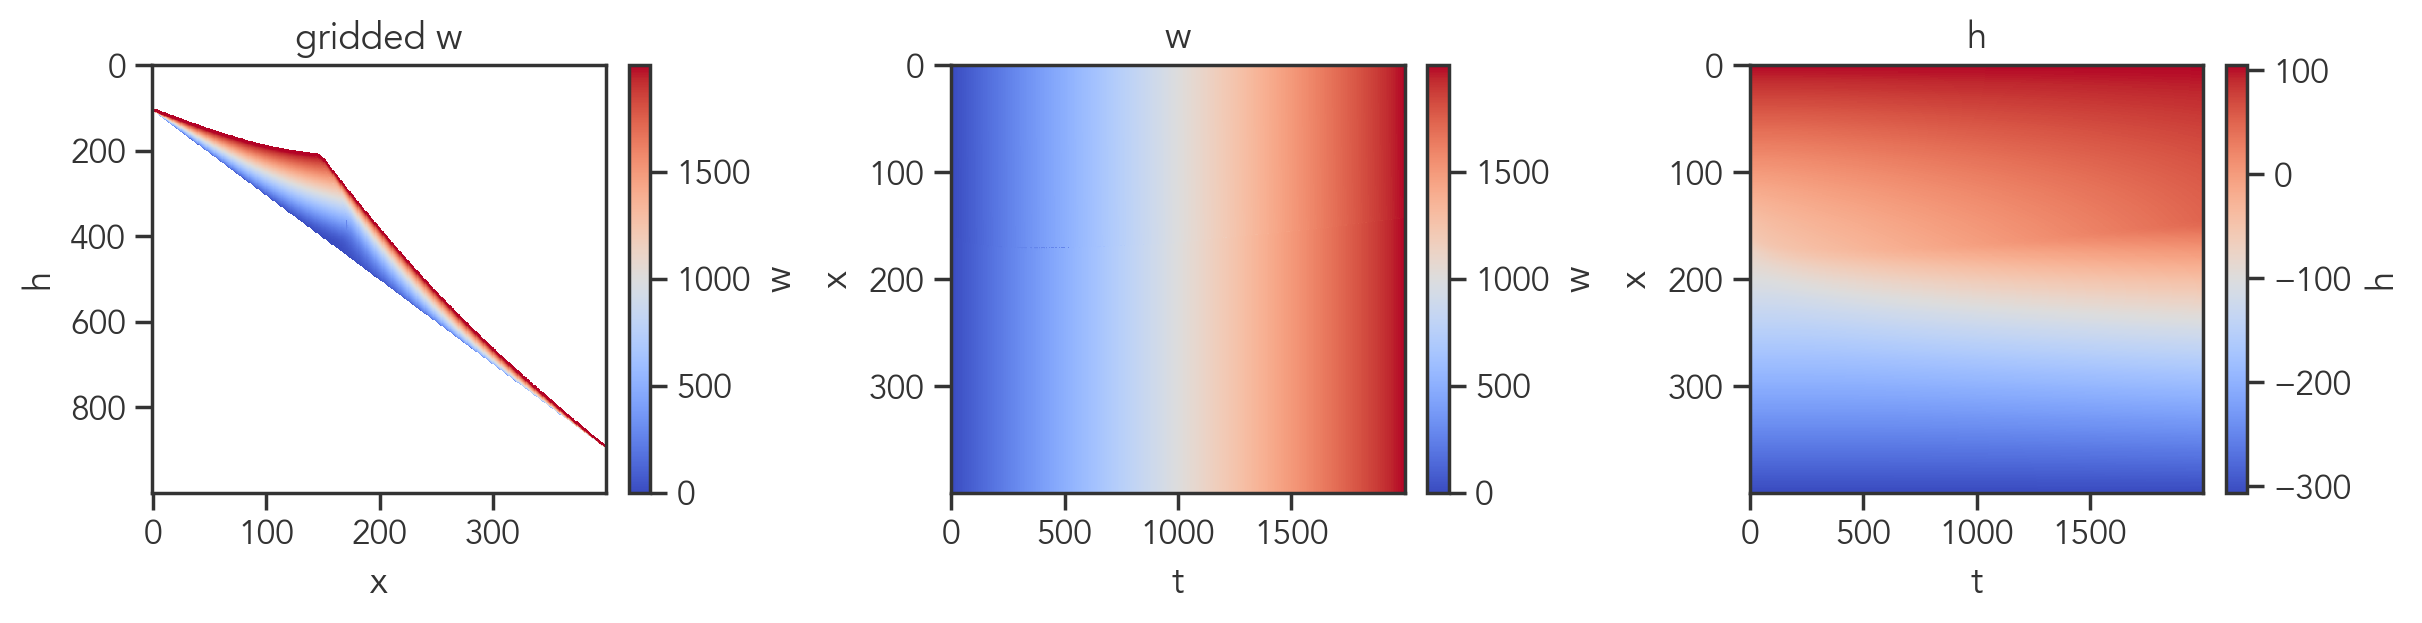

In [55]:
## model outputs
facies_data = [{'name':'Terrestrial','type': 'land','width':1,'min':1,'max':2}, # terrestrial is always everyting <0 (above water)
               {'name':'Grainstone','type': 'uniform', 'min': -0.01, 'max': max_depth/20,'width':.8}, # need this slightly modified min and the threshold below to make it work well
               {'name':'Packstone','type': 'uniform', 'min': max_depth/20, 'max': max_depth/15,'width':.6},
               {'name':'Wackestone','type': 'uniform', 'min': max_depth/15, 'max': max_depth/12,'width':.4},
               {'name':'Mudstone','type': 'uniform', 'min': max_depth/12, 'max': max_depth/10,'width':.3},
               {'name':'Shallow Marine','type': 'uniform', 'min': max_depth/10, 'max': max_depth/8,'width':.3},
               {'name':'Intermediate Marine','type': 'uniform', 'min': max_depth/8, 'max': max_depth/5,'width':.2},
               {'name':'Deep Marine','type': 'uniform', 'min': max_depth/5, 'max': max_depth,'width':.2}]

out_reg = Model_output(**mod_reg,facies_data=facies_data,facies_colours=facies_colours,bc_filter=False,set_under_c='.3',im_ylen=5000,images=True)
out_reg.plot_grids()

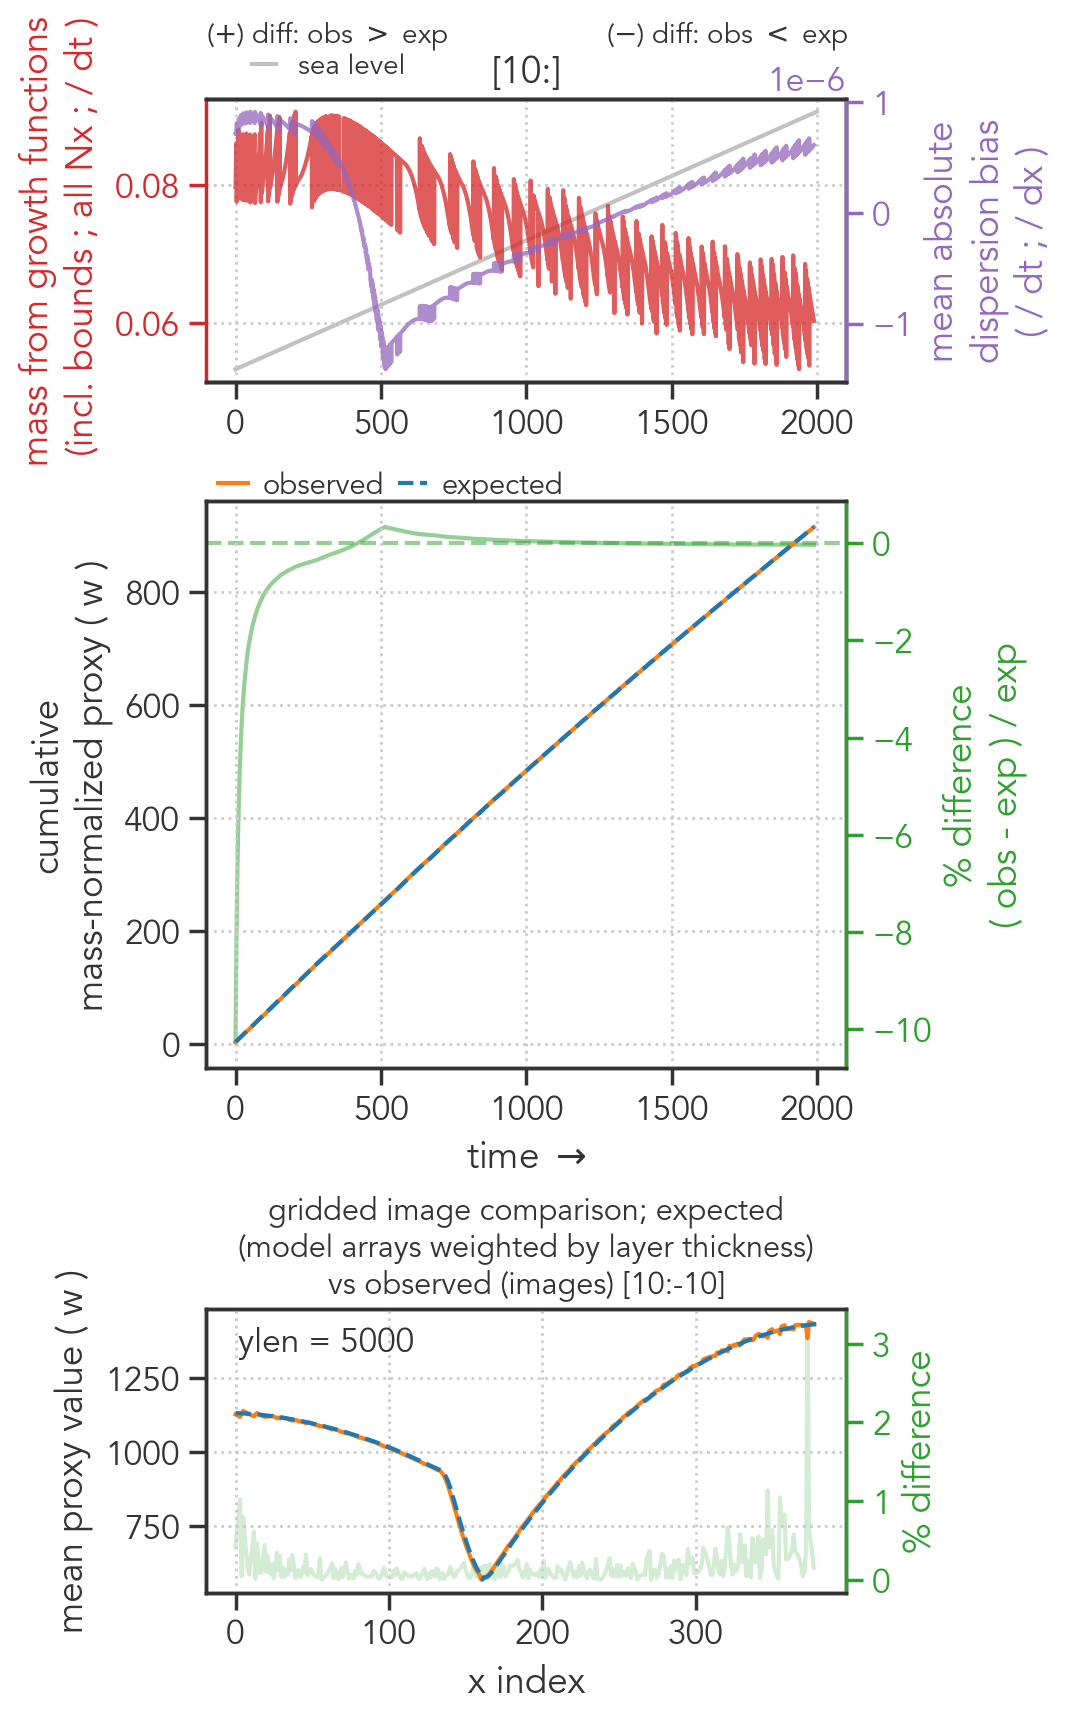

In [56]:
fig,ax,diff = out_reg.mass_balance(out=True,rsl=True,percent=True,show='proxy',start=10,im_l_lim=10,im_r_lim=-10)

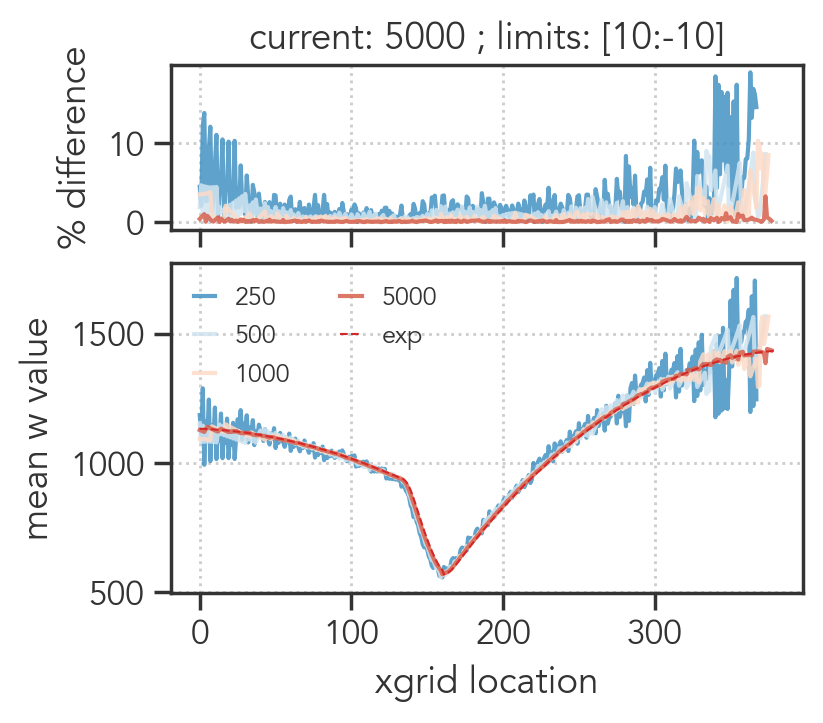

In [37]:
fig = out_reg.im_res_compare(pal='RdBu_r',ncols='multi',im_l_lim=10,im_r_lim=-10)

## Figure

In [24]:
# fig,ax = plt.subplots(3,1,figsize=(2.5,5),sharey=True,sharex=True,layout='constrained')
# #plt.subplots_adjust(hspace=0)

# # set colormap
# cmap ='viridis'

# ## progradational ##
# sm = ax[0].imshow(out_prog.im_w,aspect='auto',extent=out_prog.extent,origin='lower',cmap=cmap)
# ax[0].plot(mod_prog['x'],mod_prog['beds_eroded'][-1],color='.2',zorder=1000)
# ax[0].plot(mod_prog['x'],mod_prog['beds_eroded'][0],color='.2',zorder=1000)
# ax[0].set_xlim(1750,5000)
# ax[0].set_ylim(-250,150)

# ## aggradational ##
# sm = ax[1].imshow(out_agg.im_w,aspect='auto',extent=out_agg.extent,origin='lower',cmap=cmap)
# ax[1].plot(mod_agg['x'],mod_agg['beds_eroded'][-1],color='.2')
# ax[1].plot(mod_agg['x'],mod_agg['beds_eroded'][0],color='.2')
# # surfaces 
# # ax[1].plot(mod_agg['x'],mod_agg['beds_eroded'][out_agg.reg_idx,:].T,color='.2',alpha=1,ls='--',lw=1.125,zorder=10000,label='regressive surface');
# # ax[1].plot(mod_agg['x'],mod_agg['beds_eroded'][out_agg.tran_idx,:].T,color='.2',alpha=1,ls=':',lw=1.125,zorder=10000,label='transgressive surface');

# ## retrogradational ##
# sm = ax[2].imshow(out_reg.im_w,aspect='auto',extent=out_reg.extent,origin='lower',cmap=cmap)
# ax[2].plot(mod_reg['x'],mod_reg['beds_eroded'][-1],color='.2',zorder=1000)
# ax[2].plot(mod_reg['x'],mod_reg['beds_eroded'][0],color='.2',zorder=1000)

# # colorbar
# cbar = plt.colorbar(sm,ax=ax[2],orientation='horizontal',label='particle age (kyr)')

# # add colours to time beds
# for idx,m in enumerate([mod_prog,mod_agg,mod_reg]):
#     b = m['beds_eroded']
#     skip = 500
#     end = b.shape[0]
#     ax[idx].set_prop_cycle(cycler('color',sns.color_palette('Greys',n_colors=int(np.ceil(end/skip)))))
#     for i in range(end):
#         if i%skip==0:
#             ax[idx].plot(m['x'],b[i],alpha=0.65,lw=1)
            

# # legend
# # el = [Line2D([0], [0],mew=0.65,lw=1, marker='v', color='k', ls='--',alpha=1,label='regressive surface',markerfacecolor='none', markersize=0),
# #       Line2D([0], [0],mew=0.65,lw=1, marker='v', color='k', ls=':',alpha=1,label='transgressive surface',markerfacecolor='none', markersize=0)]
# # # using fig.legend as doesn't mess up spacing
# # leg = fig.legend(handles=el,loc=1,bbox_to_anchor=(1.15,0.635),ncols=1,frameon=False,framealpha=1,fontsize=8,handletextpad=0.4,markerfirst=True)#,handlelength=0.75)

# # format
# labs = ['A) prograde','B) aggrade','C) retrograde']
# for a,l in zip(range(3),labs):
#     ax[a].spines[['right','top']].set_visible(False)
#     ax[a].set_xticks([])
#     ax[a].set_yticks([])
#     ax[a].text(0.525,0.9,l,transform=ax[a].transAxes,fontsize=12)
#     ax[a].set_ylabel(r'topography $\rightarrow$',fontsize=12)
# #ax[2].set_xlabel(r'distance $\rightarrow$',fontsize=12)


#### Notes
- [ ] maybe re order to be prograde, retrograde, retrograde (order of complexity)

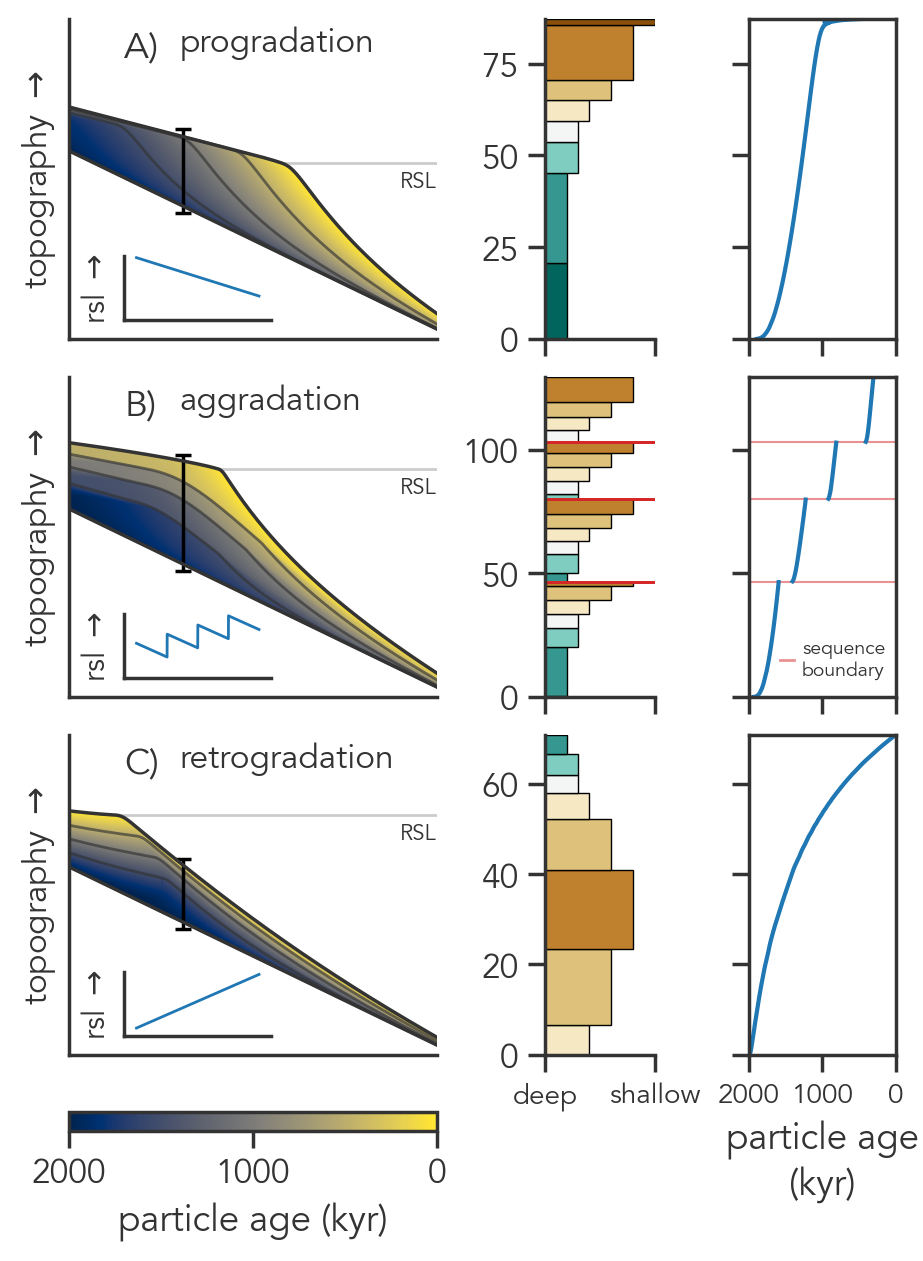

In [57]:
fig,ax = plt.subplot_mosaic(
    """
    adg
    beh
    cfi
    """, figsize=(4.5,6.25),layout='constrained',sharey=False,sharex=False,width_ratios=[1,.3,.4],height_ratios=[1,1,1]) # [1,.3,.4] figsize=(11,6) 4.5,6.2

axs = sorted(ax.keys())
# set colormap
cmap ='cividis'

## progradational ##
sm = ax['a'].imshow(out_prog.im_w,aspect='auto',extent=out_prog.extent,origin='lower',cmap=cmap,rasterized=True)
ax['a'].plot(mod_prog['x'],mod_prog['beds_eroded'][-1],color='.2',zorder=1000,lw=1.25)
ax['a'].plot(mod_prog['x'],mod_prog['beds_eroded'][0],color='.2',zorder=1000,lw=1.25)

## aggradational ##
sm = ax['b'].imshow(out_agg.im_w,aspect='auto',extent=out_agg.extent,origin='lower',cmap=cmap,rasterized=True)
ax['b'].plot(mod_agg['x'],mod_agg['beds_eroded'][-1],color='.2',zorder=1000,lw=1.25)
ax['b'].plot(mod_agg['x'],mod_agg['beds_eroded'][0],color='.2',zorder=1000,lw=1.25)
# surfaces 
# ax['b'].plot(mod_agg['x'],mod_agg['beds_eroded'][out_agg.reg_idx,:].T,color='.2',alpha=1,ls='--',lw=1.125,zorder=10000,label='regressive surface');
# ax['b'].plot(mod_agg['x'],mod_agg['beds_eroded'][out_agg.tran_idx,:].T,color='.2',alpha=1,ls=':',lw=1.125,zorder=10000,label='transgressive surface');

## retrogradational ##
sm = ax['c'].imshow(out_reg.im_w,aspect='auto',extent=out_reg.extent,origin='lower',cmap=cmap,rasterized=True)
ax['c'].plot(mod_reg['x'],mod_reg['beds_eroded'][-1],color='.2',zorder=1000,lw=1.25)
ax['c'].plot(mod_reg['x'],mod_reg['beds_eroded'][0],color='.2',zorder=1000,lw=1.25)

# colorbar
cbar = plt.colorbar(sm,ax=ax['c'],orientation='horizontal',label='particle age (kyr)',pad=-0.275)
# reverse the tick labels so it is intuitive for stratigraphic age
ticks = cbar.get_ticks()
cbar.set_ticks(ticks)  # Set original ticks
cbar.set_ticklabels([int(i) for i in ticks[::-1]])  # Reverse the tick labels

# add colours to time beds
for idx,m in enumerate([mod_prog,mod_agg,mod_reg]):
    b = m['beds_eroded']
    skip = 500
    end = b.shape[0]
    #ax[axs[idx]].set_prop_cycle(cycler('color',sns.color_palette('Greys',n_colors=int(np.ceil(end/skip)))))
    for i in range(end):
        if i%skip==0:
            ax[axs[idx]].plot(m['x'],b[i],alpha=0.65,lw=1,color='.2')
            
# format
[ax[axs[a]].set_xlim(1750,5000) for a in range(3)]
[ax[axs[a]].set_ylim(-250,150) for a in range(3)]

labs = ['progradation','aggradation','retrogradation']
for a,l in zip(range(3),labs):
    a = axs[a]
    ax[a].spines[['right','top']].set_visible(False)
    ax[a].set_xticks([])
    ax[a].set_yticks([])
    ax[a].text(0.3,0.9,l,transform=ax[a].transAxes,fontsize=12,ha='left')
    ax[a].set_ylabel(r'topography $\rightarrow$',fontsize=12)
#ax['c'].set_xlabel(r'distance $\rightarrow$',fontsize=12)

## stratigraphy ##
lidx = 2760
skip = 6

# progradation
locs = out_prog.Nx_toX(lidx,out='Nx')
targ_val_prog,new_y_val_prog,y_min,y_max,seq_y_prog = out_prog.strat_col_im(locs,targ=out_prog.im_w,out=True,plot=True,ax=ax['d'],
                                                                x_axis=True,seq_bounds=False,seq_color='tab:red',seq_lw=1)
ax['g'].plot(targ_val_prog,new_y_val_prog)#[::skip],'.',ms=3)
ax['g'].sharey(ax['d'])

# aggradation
locs = out_agg.Nx_toX(lidx,out='Nx')
targ_val_agg,new_y_val_agg,y_min,y_max,seq_y_agg = out_agg.strat_col_im(locs,targ=out_agg.im_w,out=True,plot=True,ax=ax['e'],
                                                                x_axis=True,seq_bounds=True,seq_color='tab:red',seq_lw=1)
# make discontinuous
val = targ_val_agg
grad = np.gradient(val)
mg = np.mean(grad)
vidx = np.where(grad>20*mg,np.nan,val) # find steepest jumps and chop

ax['h'].plot(vidx,new_y_val_agg) #[::skip],'.',ms=3)
ax['h'].sharey(ax['e'])
for j in seq_y_agg[1::2]:
    ax['h'].axhline(j,color='tab:red',ls='-',lw=0.75,alpha=0.5,label='sequence boundary',zorder=0)

# retrogradation
locs = out_reg.Nx_toX(lidx,out='Nx')
targ_val_reg,new_y_val_reg,y_min,y_max,seq_y_reg = out_reg.strat_col_im(locs,targ=out_reg.im_w,out=True,plot=True,ax=ax['f'],
                                                                x_axis=True,seq_bounds=False,seq_color='tab:red',seq_lw=1)

ax['i'].plot(targ_val_reg,new_y_val_reg)#[::skip],'.',ms=3)
ax['i'].sharey(ax['f'])

# format
#[ax[axs[a]].set_yticks([]) for a in range(3,6)]
ax['f'].sharex(ax['d'])
ax['e'].sharex(ax['d'])
ax['i'].sharex(ax['g'])
ax['h'].sharex(ax['g'])
[ax[a].set_xlabel(None) for a in ['d','e']]
ax['i'].set_xlabel('particle age\n(kyr)')
ax['i'].tick_params(axis='x', labelsize=10)  # change the font size of x tick labels to 12
#[ax[axs[a]].spines[['right','top','left']].set_visible(False) for a in range(6,9)]
ax['g'].set_xlim(0,2000)
ax['g'].set_xticks(np.linspace(0,2000,3));

# label sections
sbar(ax=ax['a'],x_value=lidx,ymin=-93,ymax=13,lw=1.25,capsize=3,color='k',zorder=100)
sbar(ax=ax['b'],x_value=lidx,ymin=-93,ymax=53,lw=1.25,capsize=3,color='k',zorder=100)
sbar(ax=ax['c'],x_value=lidx,ymin=-93,ymax=-5,lw=1.25,capsize=3,color='k',zorder=100)

# format
ax['f'].set_xlabel(None)
ax['f'].set_xticks([0,1],['deep','shallow'],fontsize=10)
[ax[a].tick_params(axis='x', which='both', bottom=True, labelbottom=False) for a in ['d','e']]
[ax[a].tick_params(axis='x', which='both', bottom=True, labelbottom=False) for a in ['g','h']]
ax['f'].set_xlim(0,1)
[ax[axs[a]].tick_params(axis='y', which='both', left=True, labelleft=False) for a in range(6,9)]

# add insets
for a,(m,o) in enumerate(zip([mod_prog,mod_agg,mod_reg],[out_prog,out_agg,out_reg])):
    axi = ax[axs[a]].inset_axes([0.15,0.06,0.4,0.2])
    axi.set_xticks([])
    axi.set_yticks([])
    axi.plot(t,m['rsl_strat'],lw=1) # '.8'
    axi.spines[['right','top']].set_visible(False)
    axi.set_ylabel(r'rsl $\rightarrow$',fontsize=11)
    axi.set_xlim(left=-2000,right=22000)
    axi.set_ylim(bottom=-70)
    # add sea level lines
    lx = o.shore_x(1999)
    rsl = m['rsl_strat'][-1]
    transform = blended_transform_factory(ax[axs[a]].transAxes, ax[axs[a]].transData)
    ax[axs[a]].hlines(rsl,xmin=lx,xmax=6000,color='.8',lw=1,zorder=0)
    ax[axs[a]].text(0.9,rsl-30,'RSL',fontsize=8,transform=transform)

# legend
# el = [Line2D([0], [0],mew=0.65,lw=1, marker='v', color='k', ls='--',alpha=1,label='regressive surface',markerfacecolor='none', markersize=0),
#       Line2D([0], [0],mew=0.65,lw=1, marker='v', color='k', ls=':',alpha=1,label='transgressive surface',markerfacecolor='none', markersize=0)]
el = [Line2D([0], [0],mew=0.65,lw=1, marker='v', color='tab:red', ls='-',alpha=0.5,label='sequence\nboundary',markerfacecolor='none', markersize=0)]
# using fig.legend as doesn't mess up spacing
leg = ax['h'].legend(handles=el,loc=1,bbox_to_anchor=(1.05,0.235),ncols=1,frameon=False,framealpha=1,fontsize=7,handletextpad=0.4,markerfirst=True,handlelength=0.75)

# label abc
# label
abc = [i+')' for i in string.ascii_uppercase[:3]]
bbox_props = dict(boxstyle='square,pad=0.1',edgecolor='k',facecolor='none',alpha=0.5)
for label, axis in zip(abc,axs):
    ax[axis].text(0.15,0.91,label,transform=ax[axis].transAxes,fontsize=13,ha='left',va='center')

# reverse x axis ticks
ticks = ax['i'].get_xticks()
ax['i'].set_xticks(ticks)  # Set original ticks
ax['i'].set_xticklabels([int(i) for i in ticks[::-1]])  # Reverse the tick labels

# save figure
fig.savefig(tex_fig_dir+'depo_systems.pdf',format='pdf',dpi=300,bbox_inches='tight',transparent=True)

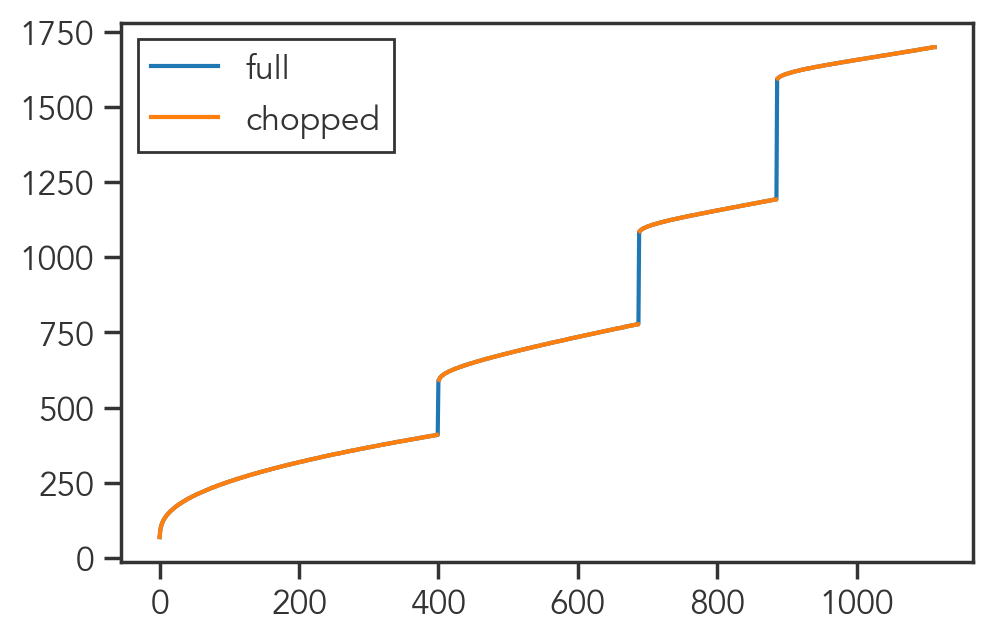

In [26]:
val = targ_val_agg
grad = np.gradient(val)
mg = np.mean(grad)
vidx = np.where(grad>20*mg,np.nan,val)
plt.plot(val,label='full')
plt.plot(vidx,label='chopped')
plt.legend()

In [27]:
print(mod_agg['rsl_strat'].min(),mod_agg['rsl_strat'].max())

-24.94727 64.91799
